# 07 — Forecast Next 3 Months per Subtopic

Forecasts both **article volume** (coverage trend) and **sentiment** per topic.

Methods:
- **Prophet** (primary) — handles seasonality, missing weeks, and trend changepoints automatically
- **SARIMA** (secondary) — classical baseline, good for stationary series
- **Comparison** — pick the better model per subtopic using RMSE on a holdout set

Input: `data/timeseries.csv`  
Output: `data/forecasts.csv` + forecast plots per topic

In [5]:
# pip install prophet pmdarima scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('data/forecast_plots', exist_ok=True)

ts = pd.read_csv('data/timeseries.csv', parse_dates=['week'])

# Backward compatibility: older files used `subtopic`, newer pipeline uses `primary_topic`.
TOPIC_COL = 'subtopic' if 'subtopic' in ts.columns else 'primary_topic'
if TOPIC_COL not in ts.columns:
    raise ValueError('timeseries.csv must contain either `subtopic` or `primary_topic`.')
if 'subtopic' not in ts.columns:
    ts['subtopic'] = ts[TOPIC_COL]

# Dynamically exclude tiny labels — no hardcoded topic names needed.
MIN_WEEKS_REQUIRED = 18
topic_week_counts = ts.groupby('subtopic')['week'].nunique()
subtopics = topic_week_counts[topic_week_counts >= MIN_WEEKS_REQUIRED].index.tolist()

print(f'Topics to forecast ({len(subtopics)}): {subtopics}')
ts.head(3)

Topics to forecast (9): ['ai', 'climate_weather', 'elections_governance', 'energy_markets', 'geopolitics_conflict', 'macroeconomy', 'public_health', 'supply_chain', 'trade_industry']


,week,primary_topic,article_count,sentiment_mean,sentiment_std,positive_ratio,negative_ratio,risk_score_mean,risk_score_max,risk_index_mean,high_risk_share,article_count_lag1,article_count_lag4,article_count_pct_change_1w,article_count_roll4_mean,risk_index_roll4_mean,subtopic
0,2022-07-18,ai,3,-0.9246,0.000000,0.0,1.0,0.0,0,0.27740,0.0,NaN,NaN,NaN,3.000000,0.27740,ai
1,2022-07-25,ai,2,0.6115,0.000000,1.0,0.0,0.0,0,0.18340,0.0,3.0,NaN,-0.333333,2.500000,0.23040,ai
2,2022-09-19,ai,6,-0.6044,0.035602,0.0,1.0,0.0,0,0.18135,0.0,2.0,NaN,2.000000,3.666667,0.21405,ai


## Helper — Build per-subtopic weekly series
Fill missing weeks with 0 (no coverage) and interpolate sentiment gaps.

In [6]:
def build_series(topic: str, value_col: str = 'article_count') -> pd.DataFrame:
    """
    Returns a clean weekly series for one subtopic.
    Reindexes to fill missing weeks.
    """
    sub = (
        ts[ts['subtopic'] == topic]
        .set_index('week')[value_col]
        .resample('W')
        .sum() if value_col == 'article_count'
        else ts[ts['subtopic'] == topic]
        .set_index('week')[value_col]
        .resample('W')
        .mean()
    )
    full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq='W')
    sub = sub.reindex(full_idx)
    if value_col == 'article_count':
        sub = sub.fillna(0)
    else:
        sub = sub.interpolate(method='time')  # sentiment: interpolate gaps
    return sub.reset_index().rename(columns={'index': 'week', value_col: 'y'})

## Step 1 — Train/Test Split
Hold out the last 8 weeks for evaluation before producing the real 3-month forecast.

In [ ]:
HOLDOUT_WEEKS = 4
FORECAST_WEEKS = 52  # ~3 months


## Step 2 — Prophet Forecaster

In [7]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

def prophet_forecast(series: pd.DataFrame, forecast_weeks: int,
                     is_count: bool = True) -> tuple:
    """
    Fits Prophet and returns (forecast_df, rmse_on_holdout).
    series: DataFrame with columns ['week', 'y']
    """
    df_p = series.rename(columns={'week': 'ds'})
    train = df_p.iloc[:-HOLDOUT_WEEKS]
    test  = df_p.iloc[-HOLDOUT_WEEKS:]

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,   # weekly doesn't apply to weekly-aggregated data
        daily_seasonality=False,
        seasonality_mode='multiplicative' if is_count else 'additive',
        changepoint_prior_scale=0.1,  # flexibility of trend; raise if underfitting
        interval_width=0.90
    )
    m.fit(train)

    # Evaluate on holdout
    future_test = m.make_future_dataframe(periods=HOLDOUT_WEEKS, freq='W')
    fc_test = m.predict(future_test)
    y_pred = fc_test.set_index('ds')['yhat'].reindex(test['ds']).values
    y_pred = np.clip(y_pred, 0, None) if is_count else y_pred
    rmse = np.sqrt(mean_squared_error(test['y'].values, y_pred))

    # Refit on full data for real forecast
    m_full = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative' if is_count else 'additive',
        changepoint_prior_scale=0.1,
        interval_width=0.90
    )
    m_full.fit(df_p)
    future_full = m_full.make_future_dataframe(periods=forecast_weeks, freq='W')
    fc_full = m_full.predict(future_full)

    if is_count:
        for col in ['yhat', 'yhat_lower', 'yhat_upper']:
            fc_full[col] = np.clip(fc_full[col], 0, None)

    return fc_full[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], rmse

## Step 3 — SARIMA Forecaster

In [9]:
from pmdarima import auto_arima

def sarima_forecast(series: pd.DataFrame, forecast_weeks: int,
                    is_count: bool = True) -> tuple:
    """
    Auto-selects SARIMA order via AIC and returns (forecast_df, rmse_on_holdout).
    """
    y = series['y'].values
    train_y = y[:-HOLDOUT_WEEKS]
    test_y  = y[-HOLDOUT_WEEKS:]
    dates   = series['week'].values

    model = auto_arima(
        train_y,
        seasonal=True,
        m=52,            # weekly seasonality period
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        max_p=3, max_q=3, max_P=2, max_Q=2,
        d=None, D=None   # let auto_arima determine differencing
    )

    # Holdout RMSE
    y_pred_test = model.predict(n_periods=HOLDOUT_WEEKS)
    if is_count:
        y_pred_test = np.clip(y_pred_test, 0, None)
    rmse = np.sqrt(mean_squared_error(test_y, y_pred_test))

    # Refit on full series
    model.update(test_y)  # incremental update
    fc_vals, conf_int = model.predict(n_periods=forecast_weeks, return_conf_int=True, alpha=0.10)

    if is_count:
        fc_vals = np.clip(fc_vals, 0, None)
        conf_int = np.clip(conf_int, 0, None)

    last_date = pd.to_datetime(dates[-1])
    future_dates = pd.date_range(last_date + pd.Timedelta(weeks=1),
                                 periods=forecast_weeks, freq='W')

    fc_df = pd.DataFrame({
        'ds': future_dates,
        'yhat': fc_vals,
        'yhat_lower': conf_int[:, 0],
        'yhat_upper': conf_int[:, 1]
    })
    return fc_df, rmse

## Step 4 — Run Both Models, Pick Better One per Subtopic
Winner is decided by holdout RMSE. Both forecasts are saved regardless.

In [10]:
all_forecasts = []
model_selection = []

for topic in subtopics:
    print(f'\n=== {topic} ===')
    series = build_series(topic, 'article_count')

    if len(series) < HOLDOUT_WEEKS + 10:
        print(f'  Skipping — insufficient data ({len(series)} weeks)')
        continue

    # Prophet
    try:
        fc_prophet, rmse_prophet = prophet_forecast(series, FORECAST_WEEKS)
        print(f'  Prophet  RMSE: {rmse_prophet:.2f}')
    except Exception as e:
        print(f'  Prophet failed: {e}')
        fc_prophet, rmse_prophet = None, np.inf

    # SARIMA
    try:
        fc_sarima, rmse_sarima = sarima_forecast(series, FORECAST_WEEKS)
        print(f'  SARIMA   RMSE: {rmse_sarima:.2f}')
    except Exception as e:
        print(f'  SARIMA failed: {e}')
        fc_sarima, rmse_sarima = None, np.inf

    # Pick winner
    if rmse_prophet <= rmse_sarima and fc_prophet is not None:
        winner, winner_fc, winner_rmse = 'Prophet', fc_prophet, rmse_prophet
    elif fc_sarima is not None:
        winner, winner_fc, winner_rmse = 'SARIMA', fc_sarima, rmse_sarima
    else:
        print('  Both models failed, skipping.')
        continue

    print(f'  Winner: {winner}')

    winner_fc = winner_fc.copy()
    winner_fc['subtopic'] = topic
    winner_fc['model'] = winner
    winner_fc['target'] = 'article_count'
    all_forecasts.append(winner_fc)

    model_selection.append({
        'subtopic': topic,
        'prophet_rmse': round(rmse_prophet, 3),
        'sarima_rmse': round(rmse_sarima, 3),
        'winner': winner
    })

model_sel_df = pd.DataFrame(model_selection)
print('\nModel selection summary:')
model_sel_df


=== ai ===


01:49:09 - cmdstanpy - INFO - Chain [1] start processing
01:49:10 - cmdstanpy - INFO - Chain [1] done processing
01:49:10 - cmdstanpy - INFO - Chain [1] start processing
01:49:11 - cmdstanpy - INFO - Chain [1] done processing


  Prophet  RMSE: 22.90


01:54:28 - cmdstanpy - INFO - Chain [1] start processing
01:54:28 - cmdstanpy - INFO - Chain [1] done processing


  SARIMA   RMSE: 36.89
  Winner: Prophet

=== climate_weather ===


...

01:58:20 - cmdstanpy - INFO - Chain [1] start processing
01:58:20 - cmdstanpy - INFO - Chain [1] done processing


  SARIMA   RMSE: 1.31
  Winner: SARIMA

=== trade_industry ===


01:58:20 - cmdstanpy - INFO - Chain [1] start processing
01:58:20 - cmdstanpy - INFO - Chain [1] done processing


  Prophet  RMSE: 2.60
  SARIMA   RMSE: 2.35
  Winner: SARIMA

Model selection summary:


,subtopic,prophet_rmse,sarima_rmse,winner
0,ai,22.896,36.892,Prophet
1,climate_weather,16.174,11.034,SARIMA
2,elections_governance,19.154,7.860,SARIMA
3,energy_markets,15.630,9.047,SARIMA
4,geopolitics_conflict,79.906,124.929,Prophet
5,macroeconomy,18.489,21.868,Prophet
6,public_health,62.763,28.824,SARIMA
7,supply_chain,2.586,1.307,SARIMA
8,trade_industry,2.598,2.347,SARIMA


## Step 5 — Also Forecast Sentiment per Subtopic
Same pipeline, just switch to `sentiment_mean` column.

In [11]:
for topic in subtopics:
    series_sent = build_series(topic, 'sentiment_mean')

    if len(series_sent) < HOLDOUT_WEEKS + 10 or series_sent['y'].isna().all():
        continue

    try:
        fc_s, rmse_s = prophet_forecast(series_sent, FORECAST_WEEKS, is_count=False)
    except Exception:
        try:
            fc_s, rmse_s = sarima_forecast(series_sent, FORECAST_WEEKS, is_count=False)
        except Exception:
            continue

    fc_s = fc_s.copy()
    fc_s['subtopic'] = topic
    fc_s['model'] = 'Prophet'
    fc_s['target'] = 'sentiment_mean'
    all_forecasts.append(fc_s)

forecast_df = pd.concat(all_forecasts, ignore_index=True)
forecast_df.to_csv('data/forecasts.csv', index=False)
print(f'Saved: data/forecasts.csv — {len(forecast_df)} forecast rows')

01:59:05 - cmdstanpy - INFO - Chain [1] start processing
01:59:05 - cmdstanpy - INFO - Chain [1] done processing
01:59:05 - cmdstanpy - INFO - Chain [1] start processing
01:59:05 - cmdstanpy - INFO - Chain [1] done processing
01:59:05 - cmdstanpy - INFO - Chain [1] start processing
01:59:05 - cmdstanpy - INFO - Chain [1] done processing
01:59:05 - cmdstanpy - INFO - Chain [1] start processing
01:59:05 - cmdstanpy - INFO - Chain [1] done processing
01:59:05 - cmdstanpy - INFO - Chain [1] start processing
01:59:05 - cmdstanpy - INFO - Chain [1] done processing
01:59:05 - cmdstanpy - INFO - Chain [1] start processing
01:59:05 - cmdstanpy - INFO - Chain [1] done processing
01:59:05 - cmdstanpy - INFO - Chain [1] start processing
01:59:05 - cmdstanpy - INFO - Chain [1] done processing
01:59:05 - cmdstanpy - INFO - Chain [1] start processing
01:59:05 - cmdstanpy - INFO - Chain [1] done processing
01:59:06 - cmdstanpy - INFO - Chain [1] start processing
01:59:06 - cmdstanpy - INFO - Chain [1]

Saved: data/forecasts.csv — 3262 forecast rows


## Step 6 — Plot: Historical + Forecast per Subtopic
One combined plot per subtopic: top panel = article volume, bottom = sentiment.

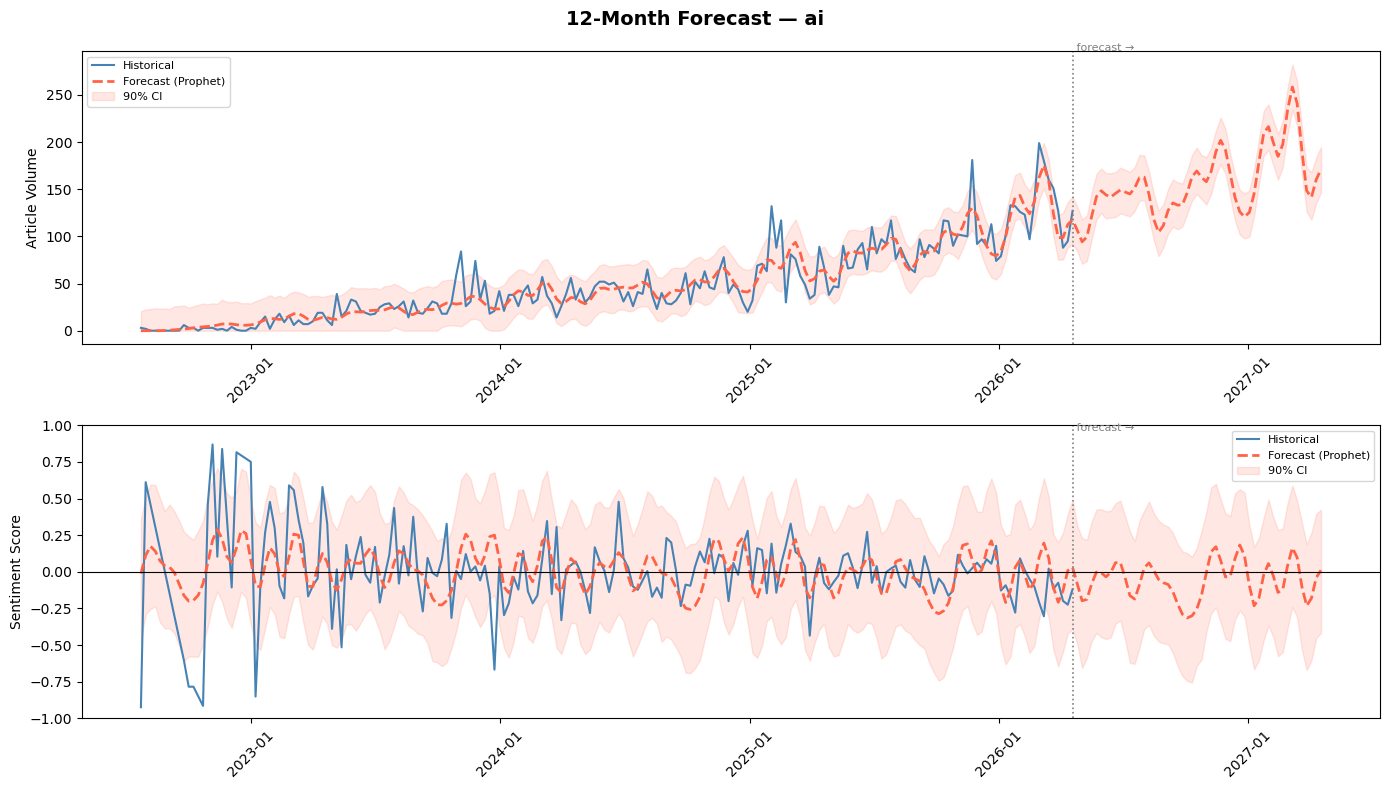

Saved: data/forecast_plots/ai.png


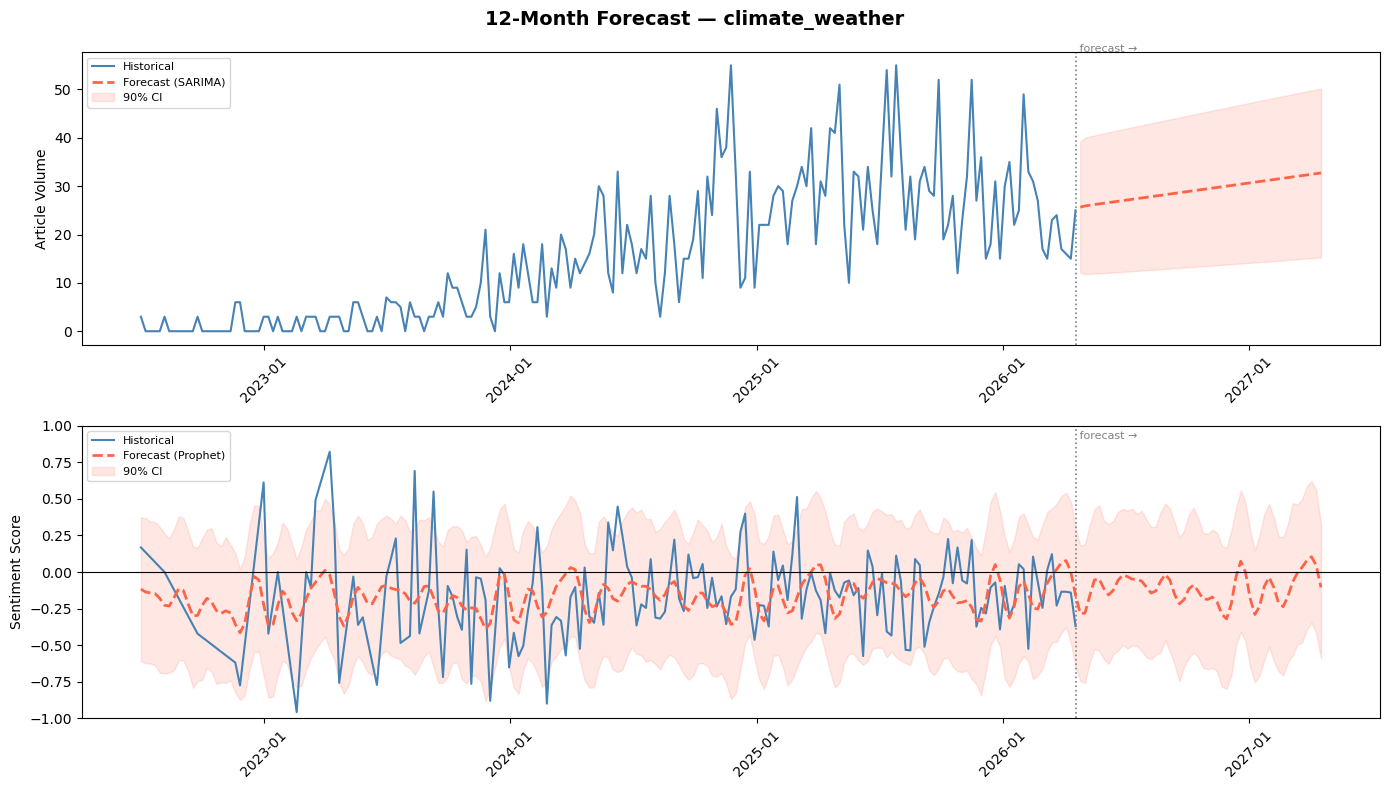

Saved: data/forecast_plots/climate_weather.png


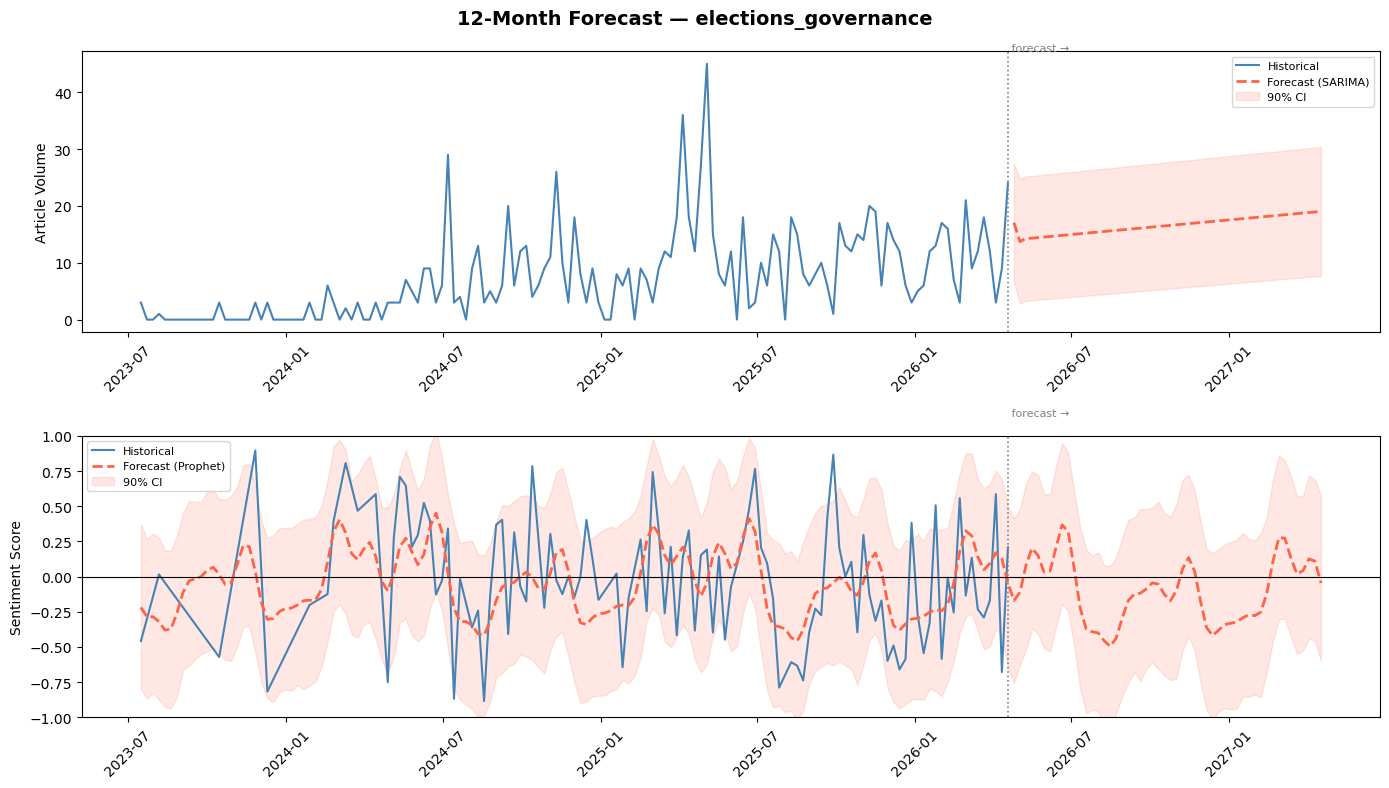

Saved: data/forecast_plots/elections_governance.png


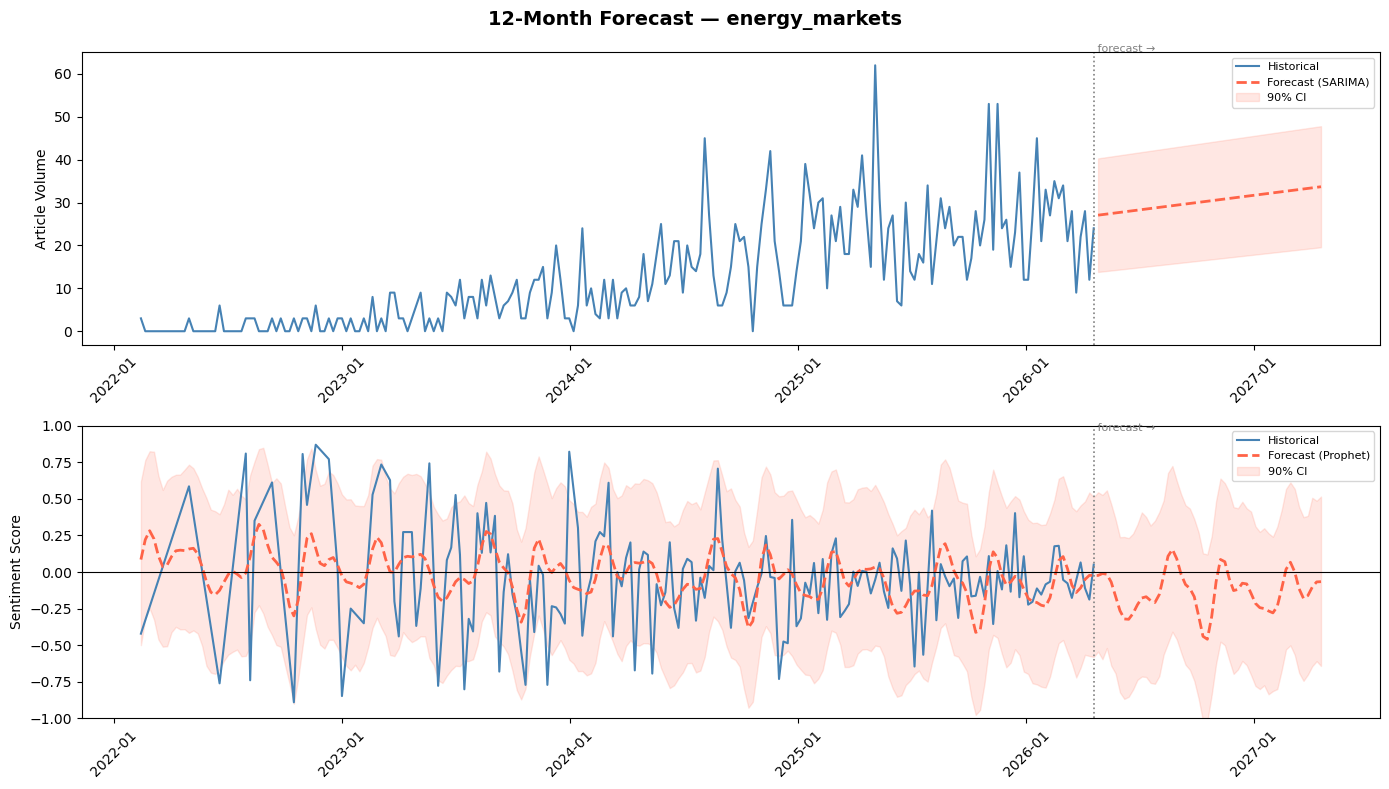

Saved: data/forecast_plots/energy_markets.png


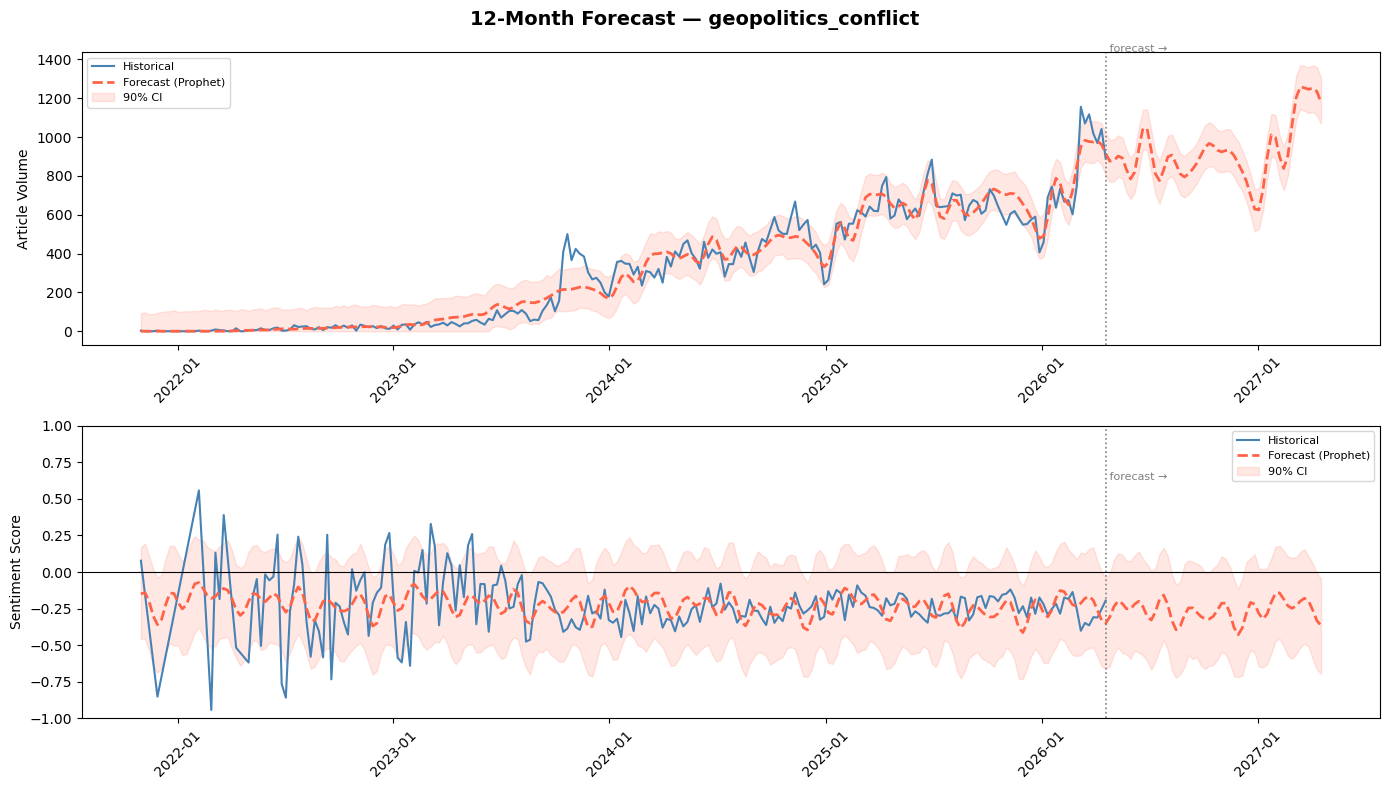

Saved: data/forecast_plots/geopolitics_conflict.png


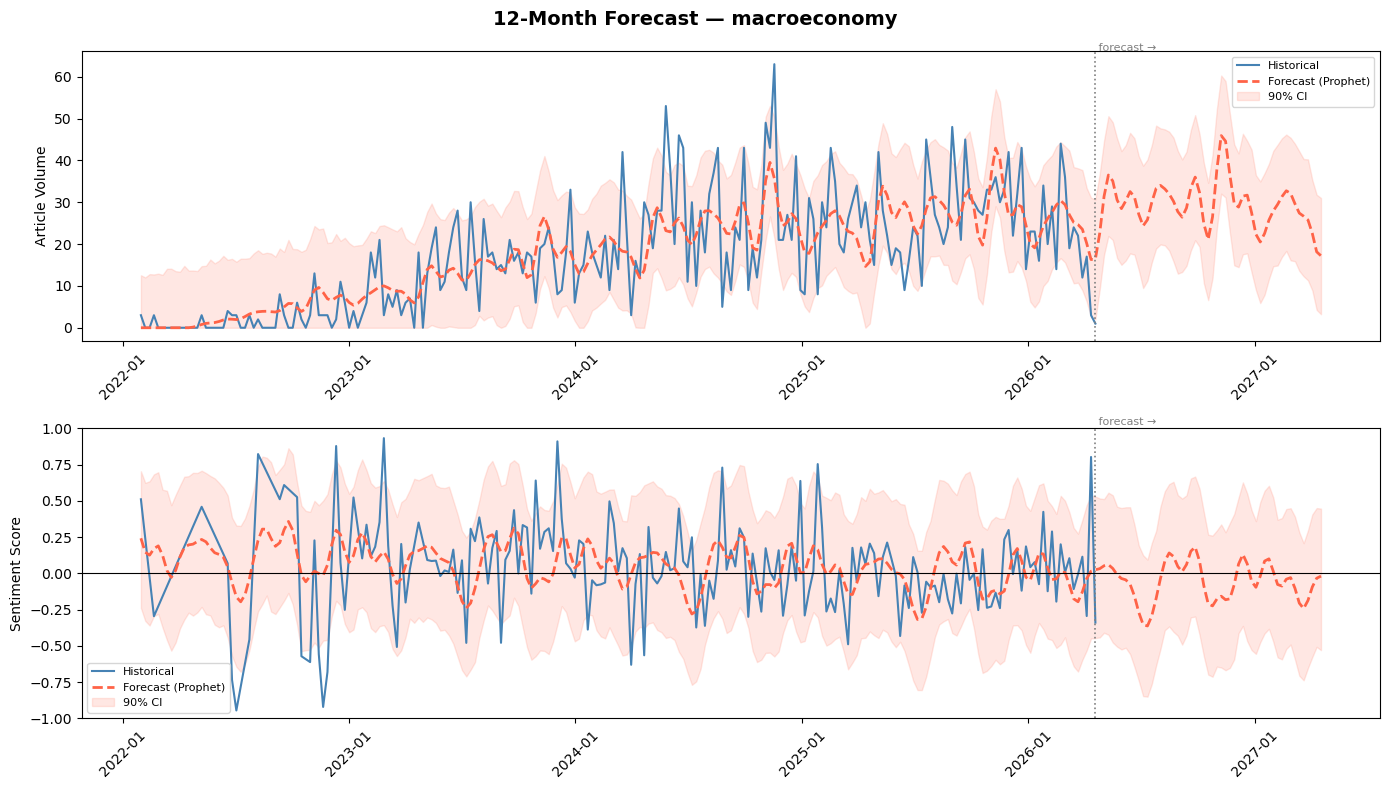

Saved: data/forecast_plots/macroeconomy.png


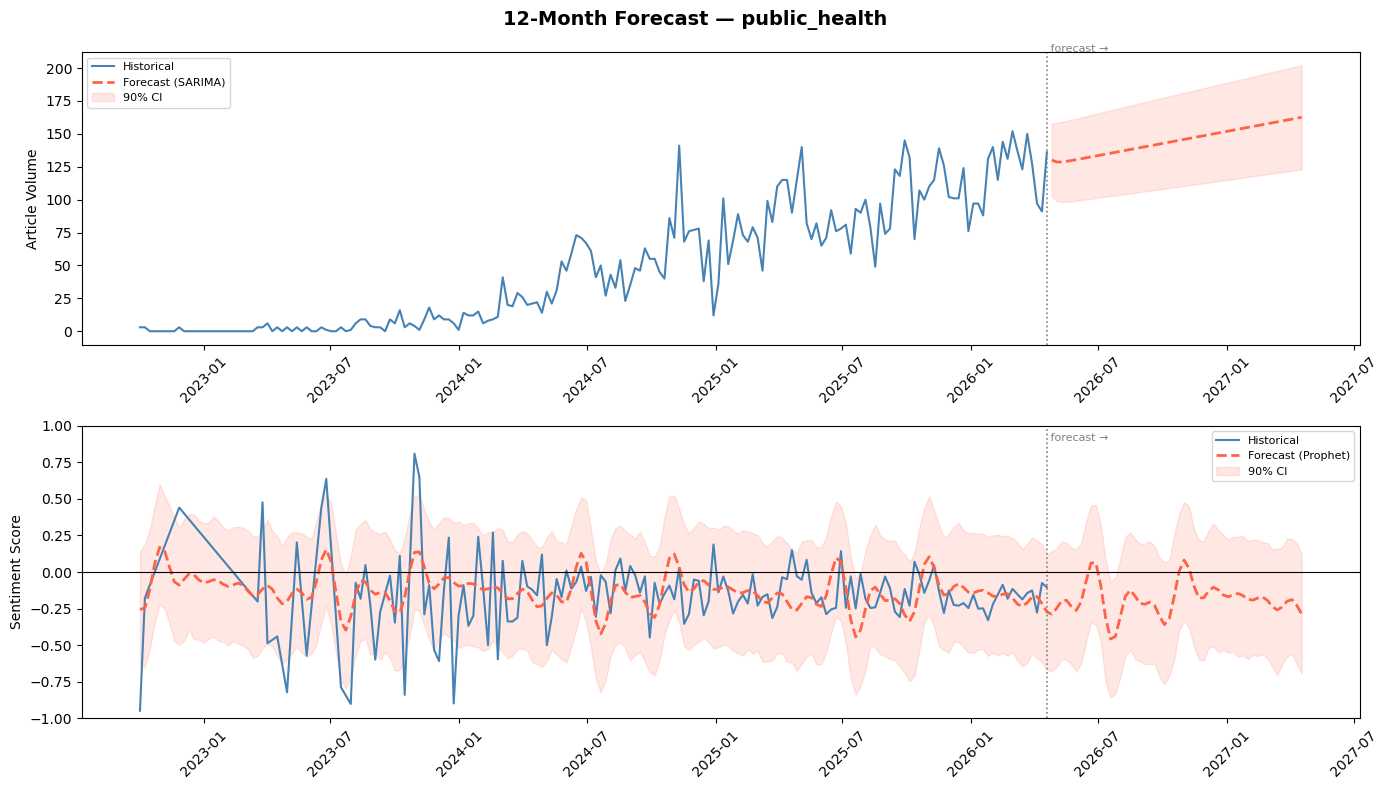

Saved: data/forecast_plots/public_health.png


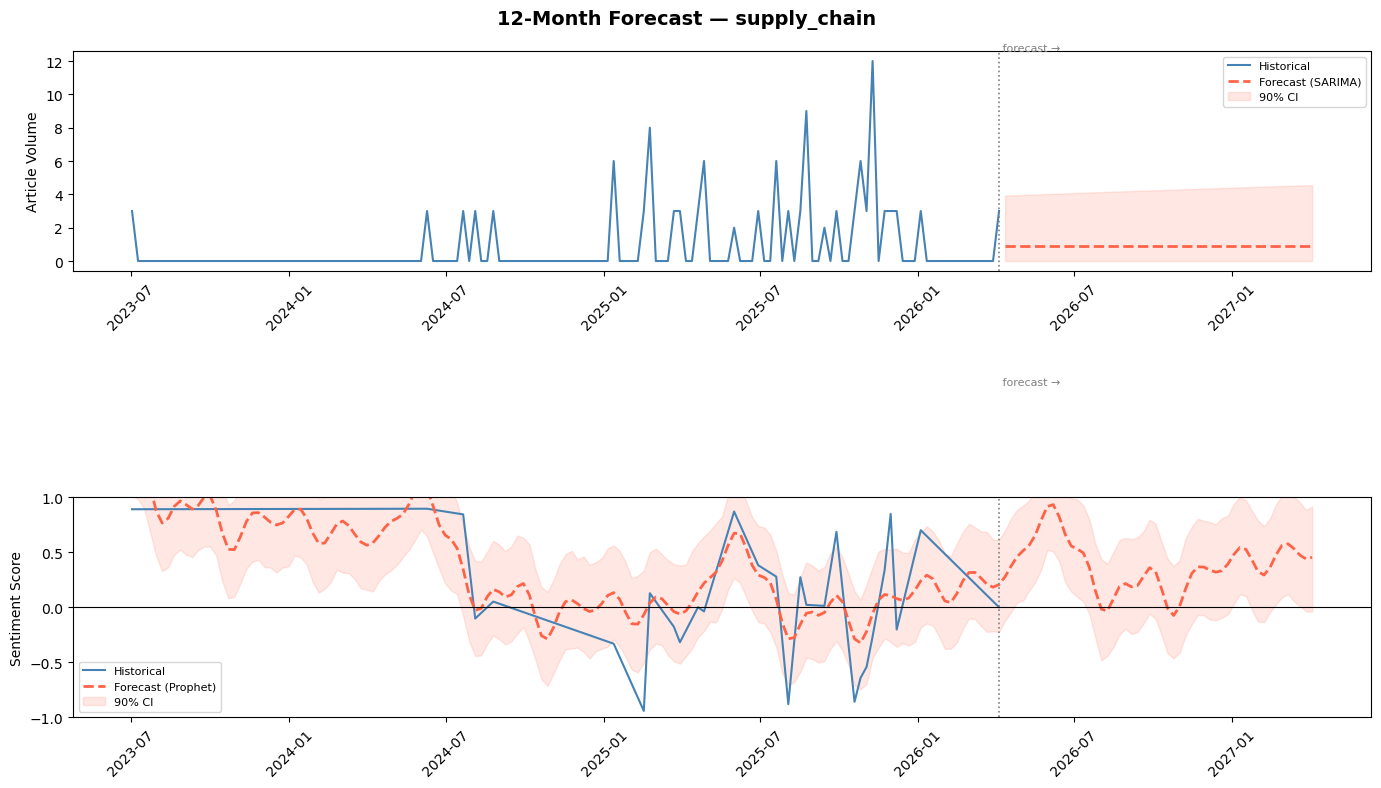

Saved: data/forecast_plots/supply_chain.png


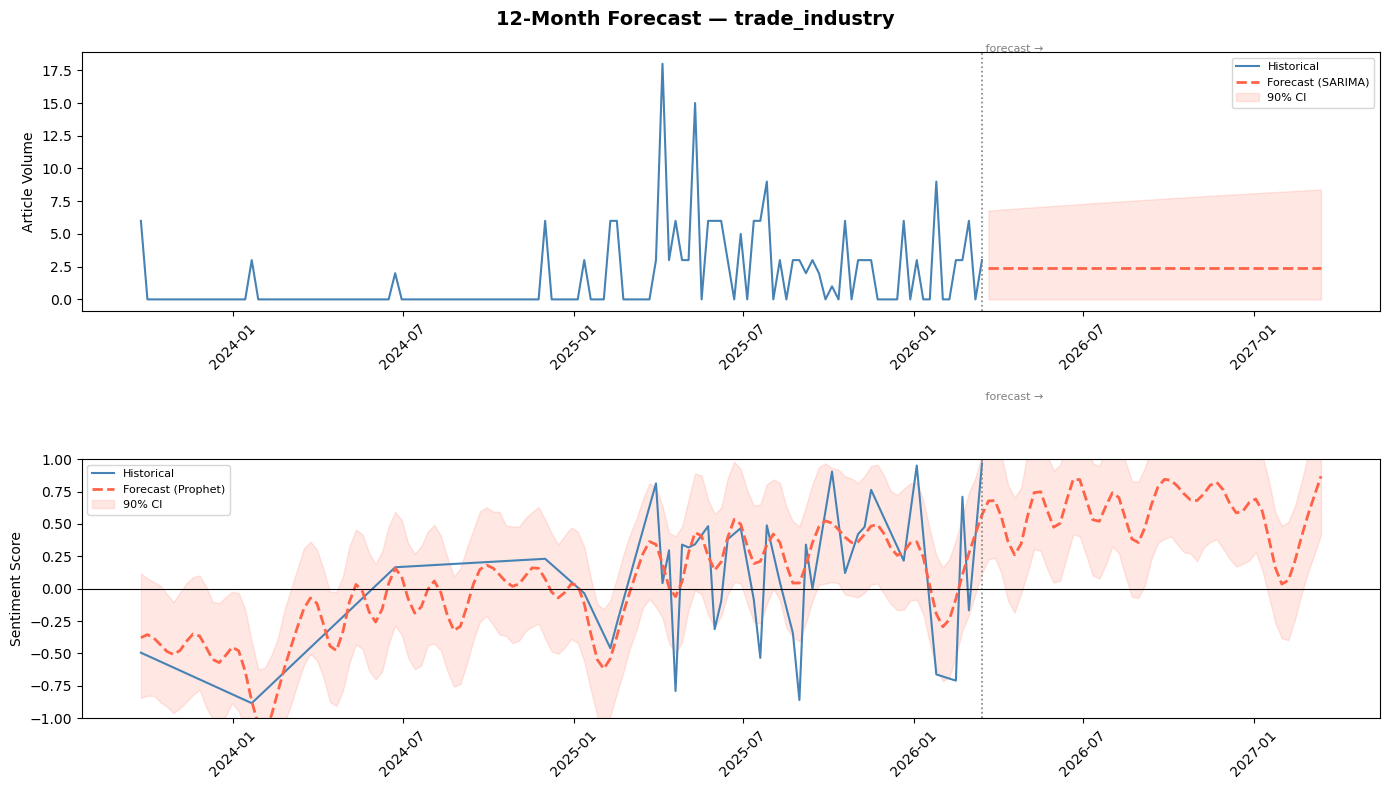

Saved: data/forecast_plots/trade_industry.png


In [12]:
def plot_subtopic_forecast(topic: str):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
    fig.suptitle(f'12-Month Forecast — {topic}', fontsize=14, fontweight='bold')

    targets = [
        ('article_count', 'Article Volume', axes[0]),
        ('sentiment_mean', 'Sentiment Score', axes[1])
    ]

    for col, ylabel, ax in targets:
        # Historical
        hist = build_series(topic, col)
        ax.plot(hist['week'], hist['y'], color='steelblue', linewidth=1.5, label='Historical')

        # Forecast
        fc = forecast_df[
            (forecast_df['subtopic'] == topic) &
            (forecast_df['target'] == col)
        ]
        if not fc.empty:
            ax.plot(fc['ds'], fc['yhat'], color='tomato', linewidth=2,
                    linestyle='--', label=f"Forecast ({fc['model'].iloc[0]})")
            ax.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'],
                            color='tomato', alpha=0.15, label='90% CI')

        # Mark forecast boundary
        boundary = hist['week'].max()
        ax.axvline(boundary, color='gray', linestyle=':', linewidth=1.2)
        ax.text(boundary, ax.get_ylim()[1], ' forecast →', fontsize=8, color='gray')

        if col == 'sentiment_mean':
            ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
            ax.set_ylim(-1, 1)

        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    path = f'data/forecast_plots/{topic.replace("/", "-").replace(" ", "_")}.png'
    plt.savefig(path, dpi=150)
    plt.show()
    print(f'Saved: {path}')


for topic in subtopics:
    if topic in forecast_df['subtopic'].unique():
        plot_subtopic_forecast(topic)

## Step 7 — Summary: Which Subtopics Are Rising vs Declining?

In [13]:
summary_rows = []

for topic in subtopics:
    fc = forecast_df[
        (forecast_df['subtopic'] == topic) &
        (forecast_df['target'] == 'article_count')
    ]
    hist = build_series(topic, 'article_count')

    if fc.empty or len(hist) < 4:
        continue

    # Compare last 4 weeks avg vs forecast avg
    recent_avg  = hist['y'].iloc[-4:].mean()
    forecast_avg = fc['yhat'].mean()
    change_pct = ((forecast_avg - recent_avg) / (recent_avg + 1e-9)) * 100

    direction = 'Rising' if change_pct > 5 else ('Declining' if change_pct < -5 else 'Stable')

    summary_rows.append({
        'subtopic': topic,
        'recent_avg_articles': round(recent_avg, 1),
        'forecast_avg_articles': round(forecast_avg, 1),
        'change_%': round(change_pct, 1),
        'trend': direction,
        'model': fc['model'].iloc[0]
    })

summary_df = pd.DataFrame(summary_rows).sort_values('change_%', ascending=False)
summary_df.to_csv('data/forecast_summary.csv', index=False)
print('Saved: data/forecast_summary.csv\n')
summary_df

Saved: data/forecast_summary.csv



,subtopic,recent_avg_articles,forecast_avg_articles,change_%,trend,model
5,macroeconomy,8.2,19.6,137.5,Rising,Prophet
1,climate_weather,18.2,29.3,60.3,Rising,SARIMA
3,energy_markets,21.5,30.4,41.3,Rising,SARIMA
2,elections_governance,12.0,16.6,38.2,Rising,SARIMA
6,public_health,112.8,144.8,28.4,Rising,SARIMA
7,supply_chain,0.8,0.9,17.5,Rising,SARIMA
8,trade_industry,3.0,2.4,-20.6,Declining,SARIMA
0,ai,109.2,72.0,-34.1,Declining,Prophet
4,geopolitics_conflict,979.8,423.7,-56.8,Declining,Prophet


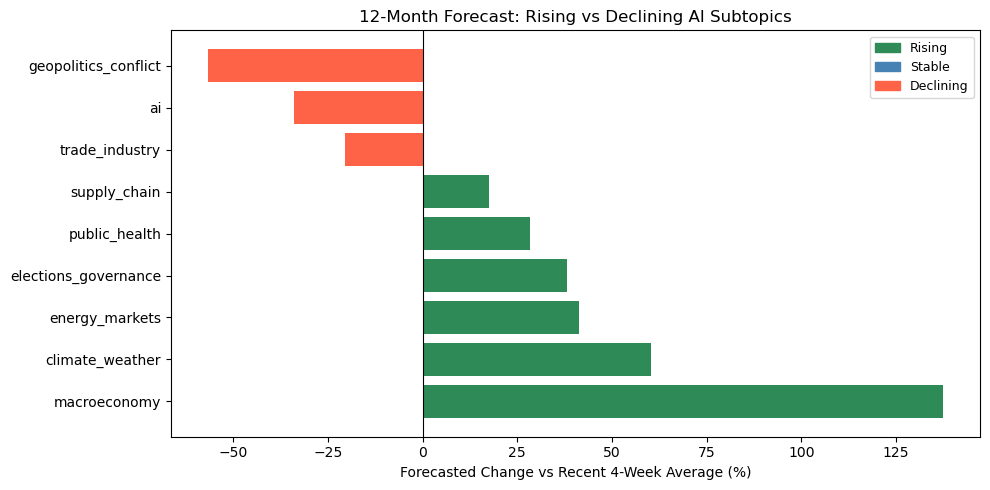

In [14]:
# Bar chart: trend direction per subtopic — good for presentation slide
colors = summary_df['trend'].map({'Rising': 'seagreen', 'Stable': 'steelblue', 'Declining': 'tomato'})

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(summary_df['subtopic'], summary_df['change_%'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Forecasted Change vs Recent 4-Week Average (%)')
ax.set_title('12-Month Forecast: Rising vs Declining AI Subtopics')

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='seagreen', label='Rising'), Patch(color='steelblue', label='Stable'),
          Patch(color='tomato', label='Declining')]
ax.legend(handles=legend, fontsize=9)

plt.tight_layout()
plt.savefig('data/forecast_summary_chart.png', dpi=150)
plt.show()